# Notebook 5 — Business Analysis & Advanced Insights
## Introduction

In this stage, we move from statistical exploration to business-driven analytics.

The goal is to:
- identify key drivers of customer support demand
- understand operational inefficiencies
- analyze customer satisfaction patterns
- build quality metrics aligned with real-world QA processes

This notebook also introduces an advanced layer: Agent Quality Audit Automation, simulating how Quality Analysts evaluate agent performance in real systems.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("Data/customer_support_summary.csv")
df.head()

,unique_id,category,sub_category,channel_name,resolution_time,handling_time_minutes,csat_score,customer_satisfaction_category,has_customer_remark,has_handling_time,agent_name,supervisor,manager,tenure_bucket,agent_shift,agent_quality_score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Product Queries,Life Insurance,Outcall,34.0,NaN,5,High,0,0,Victoria Anderson,Wyatt Kim,Jennifer Nguyen,On Job Training,Morning,2.508571
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Product Queries,Product Specific Information,Outcall,2.0,NaN,5,High,0,0,Anthony Bowen,Olivia Suzuki,Jennifer Nguyen,On Job Training,Morning,2.600000
2,200814dd-27c7-4149-ba2b-bd3af3092880,Order Related,Installation/Demo,Inbound,22.0,NaN,5,High,0,0,Paul Gill,Brayden Wong,Jennifer Nguyen,On Job Training,Morning,2.513043
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Returns,Reverse Pickup Enquiry,Inbound,20.0,NaN,5,High,0,0,John Bell,Ava Wong,William Kim,On Job Training,Evening,2.514286
4,ba903143-1e54-406c-b969-46c52f92e5df,Cancellation,Not Needed,Inbound,2.0,NaN,5,High,0,0,David Copeland,Ava Wong,Jennifer Nguyen,On Job Training,Morning,2.600000


# Research Questions and Key Findings

## Q1 — Which Issue Categories Drive the Most Support Demand?

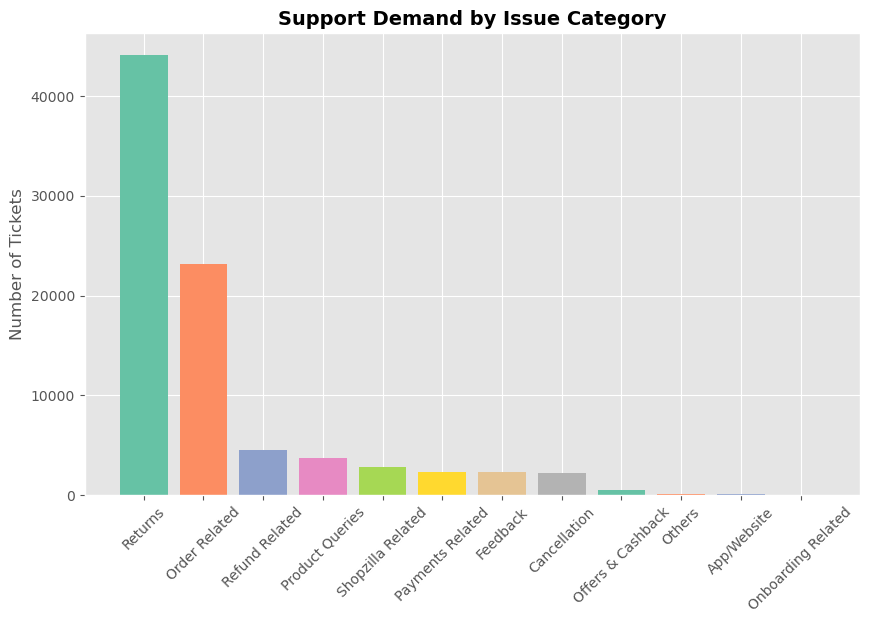

In [4]:
category_counts = df["category"].value_counts()

plt.figure(figsize=(10,6))
colors = plt.cm.Set2.colors

plt.bar(category_counts.index, category_counts.values, color=colors)

plt.xticks(rotation=45)
plt.title("Support Demand by Issue Category", fontsize=14, fontweight="bold")
plt.ylabel("Number of Tickets")

plt.show()

### Observations & Insights

The analysis clearly shows that **Returns** is the most dominant category, generating the highest number of support tickets by a significant margin. This is followed by **Order Related** issues, which also contribute a large share of total support demand.

Categories such as **Refund Related**, **Product Queries**, and **Shopzilla Related** have moderate volumes, while others like **Offers & Cashback**, **App/Website**, and **Onboarding Related** contribute very minimally.

#### Key Insight
Customer support demand is heavily concentrated around **post-purchase processes**, especially returns and order management.

### Business Implication

Since **Returns and Order Related issues** account for the majority of support tickets, improving these processes can significantly reduce overall support demand.

Key focus areas:
- Simplify and streamline the **returns process**
- Improve **order tracking transparency**
- Enable **self-service options** for common order-related queries

Addressing these high-volume categories can lead to **reduced operational load and improved customer experience**.

## Q2 — Which Issues Take the Longest to Resolve?

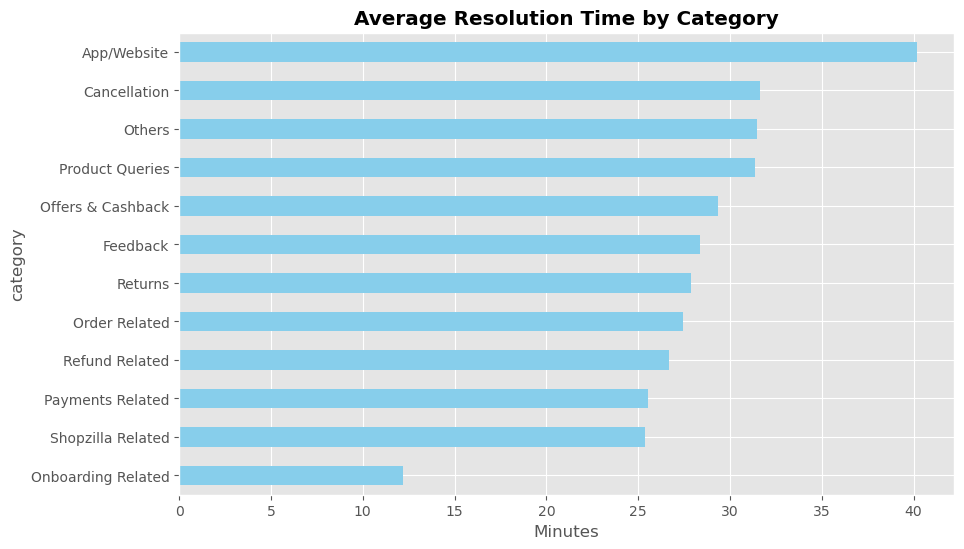

In [5]:
res_time = df.groupby("category")["resolution_time"].mean().sort_values()

plt.figure(figsize=(10,6))
res_time.plot(kind="barh", color="skyblue")

plt.title("Average Resolution Time by Category", fontweight="bold")
plt.xlabel("Minutes")

plt.show()

### Observations & Insights

The analysis shows that **App/Website issues have the highest average resolution time**, making them the most time-consuming to resolve. This is followed by **Cancellation**, **Others**, and **Product Queries**, which also require relatively longer resolution durations.

Mid-range categories include **Offers & Cashback**, **Feedback**, **Returns**, and **Order Related**, indicating moderate resolution times. In contrast, **Payments Related**, **Shopzilla Related**, and especially **Onboarding Related** have the lowest resolution times, suggesting quicker issue resolution.

#### Key Insight
Resolution time varies significantly across categories, with **technical issues and complex processes (App/Website, Cancellation)** taking the longest, while simpler or more standardized issues are resolved faster.

### Business Implication

Categories with higher resolution times represent **operational bottlenecks** and should be prioritized for improvement.

Recommended actions:
- Strengthen **technical support systems** for App/Website issues
- Streamline **cancellation workflows**
- Introduce **automation and predefined resolution paths** for complex queries

Reducing resolution time in these high-impact categories can improve **operational efficiency, SLA performance, and customer satisfaction**.

## Q3 — How Does Resolution Time Impact Customer Satisfaction?

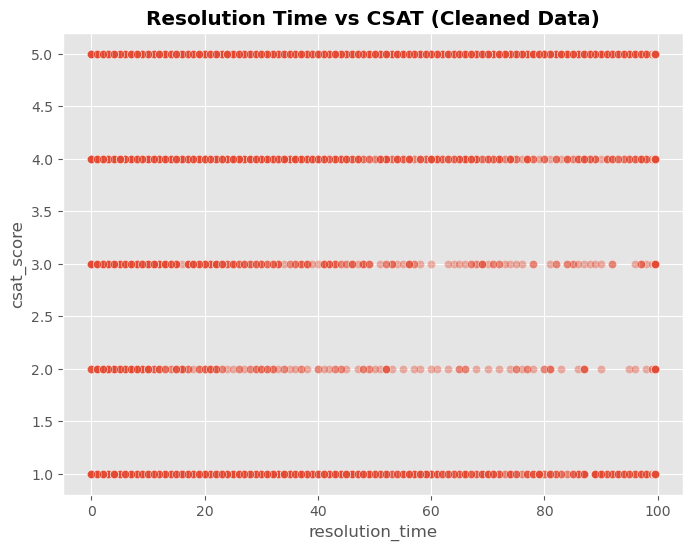

In [6]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="resolution_time",
    y="csat_score",
    alpha=0.4
)

plt.title("Resolution Time vs CSAT (Cleaned Data)", fontweight="bold")
plt.show()

### Observations & Insights

The scatter plot shows that **CSAT scores are distributed across all resolution times**, with a strong concentration of ratings at **4 and 5 regardless of how long the issue took to resolve**.

There is **no clear linear relationship** between resolution time and customer satisfaction. While some lower CSAT scores (1–3) appear at higher resolution times, they are also present at lower resolution times.

#### Key Insight
Customer satisfaction is **not solely dependent on resolution time**. Even when resolution takes longer, customers can still report high satisfaction if the issue is handled effectively.

### Business Implication

Improving customer satisfaction requires focusing on **quality of service rather than just speed**.

Key focus areas:
- Clear and effective **communication during resolution**
- Providing **accurate and complete solutions**
- Demonstrating **empathy and professionalism**

While reducing resolution time is important for efficiency, **service quality and issue resolution effectiveness have a greater impact on customer satisfaction**.

## Q4 — Which Sub-Categories Are the Biggest Pain Points?

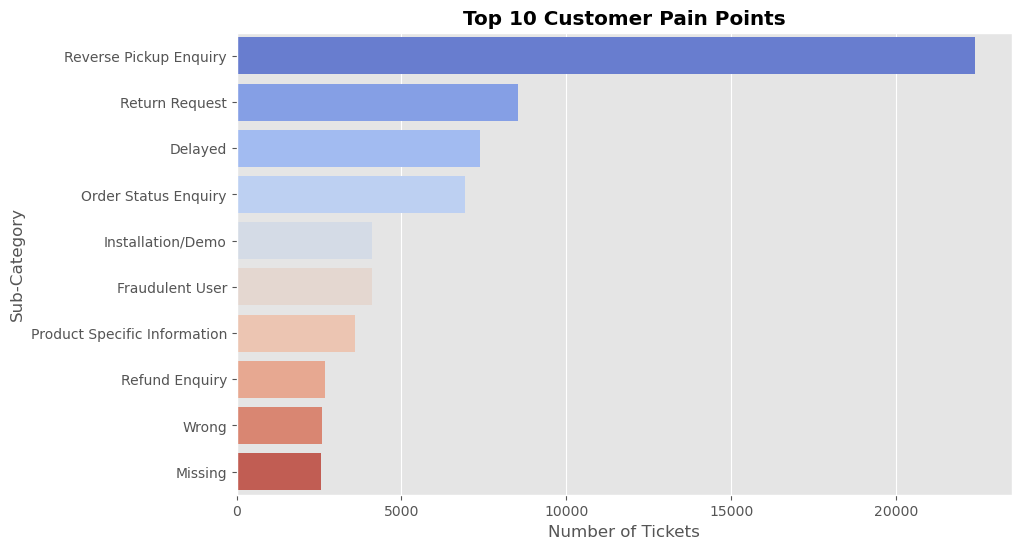

In [7]:
top_subcat = df["sub_category"].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_subcat.values,
    y=top_subcat.index,
    hue=top_subcat.index,
    palette="coolwarm",
    legend=False
)

plt.title("Top 10 Customer Pain Points", fontweight="bold")
plt.xlabel("Number of Tickets")
plt.ylabel("Sub-Category")

plt.show()

### Observations & Insights

The analysis shows that **"Reverse Pickup Enquiry"** is the most significant customer pain point, with a substantially higher number of tickets compared to all other sub-categories. This is followed by **"Return Request"**, **"Delayed"**, and **"Order Status Enquiry"**, which also contribute heavily to support demand.

Other sub-categories such as **"Installation/Demo"**, **"Fraudulent User"**, and **"Product Specific Information"** appear moderately, while issues like **"Refund Enquiry"**, **"Wrong"**, and **"Missing"** have relatively lower frequencies.

#### Key Insight
Customer pain points are highly concentrated around **return processes, delivery delays, and order tracking issues**, indicating friction in post-purchase operations.

### Business Implication

Addressing the top pain points—especially **reverse pickup and return-related issues**—can significantly reduce support volume.

Key actions:
- Optimize and automate the **reverse pickup process**
- Improve **delivery timelines and delay communication**
- Provide better **order tracking visibility and self-service options**

Fixing these high-frequency issues can lead to a **substantial reduction in support tickets and improved customer experience**.

## Q5 — How Does Customer Feedback Relate to Satisfaction?

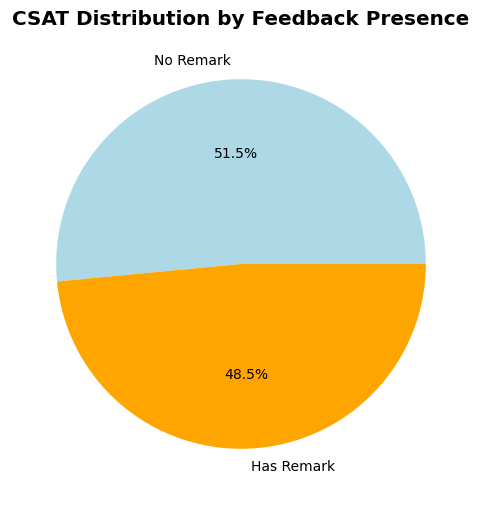

In [8]:
feedback_csat = df.groupby("has_customer_remark")["csat_score"].mean()

plt.figure(figsize=(6,6))

plt.pie(
    feedback_csat,
    labels=["No Remark", "Has Remark"],
    autopct="%1.1f%%",
    colors=["lightblue", "orange"]
)

plt.title("CSAT Distribution by Feedback Presence", fontweight="bold")

plt.show()

### Observations & Insights

The chart shows that **51.5% of the overall CSAT contribution comes from customers who did not leave remarks**, while **48.5% comes from customers who provided feedback**. The distribution is relatively balanced, with a slight majority of satisfaction scores coming from customers without remarks.

This indicates that **a large portion of customer satisfaction data exists without qualitative feedback**, and customers do not always leave remarks even when they are satisfied or dissatisfied.

#### Key Insight
Customer feedback (remarks) is **not consistently provided**, but when present, it represents a significant portion of customer experience data.

### Business Implication

Customer remarks are a valuable source of **qualitative insights**, even though they are not present in all interactions.

To maximize value:
- Encourage more customers to leave feedback
- Analyze remark data to identify **pain points and improvement areas**
- Use feedback to enhance **quality audits and agent performance evaluation**

Improving feedback collection can help uncover **deeper insights into customer experience beyond CSAT scores**.

## Q6 — Which Channels Drive Most Support Interactions?

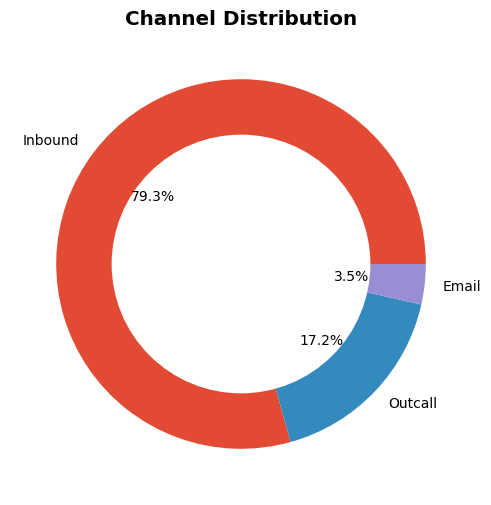

In [9]:
channel_counts = df["channel_name"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(channel_counts, labels=channel_counts.index, autopct="%1.1f%%")

# Donut
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Channel Distribution", fontweight="bold")

plt.show()

### Observations & Insights

The analysis shows that the **Inbound channel accounts for approximately 79.3% of all customer interactions**, making it the dominant communication channel by a large margin. 

**Outcall interactions contribute around 17.2%**, while **Email accounts for only 3.5%**, indicating minimal usage compared to other channels.

#### Key Insight
Customer support is highly **inbound-driven**, with the majority of customers actively reaching out for assistance rather than relying on proactive or asynchronous communication channels.

### Business Implication

The heavy dependence on inbound interactions suggests a **reactive support model**, which can increase operational load and costs.

To improve efficiency:
- Introduce **self-service solutions** (FAQs, chatbots, help centers)
- Enable **proactive communication** (order updates, return tracking)
- Reduce unnecessary inbound queries through **better product and process clarity**

Shifting some load away from inbound channels can significantly improve **scalability, cost efficiency, and customer experience**.

## Q7 — Resolution Time Distribution (Histogram)

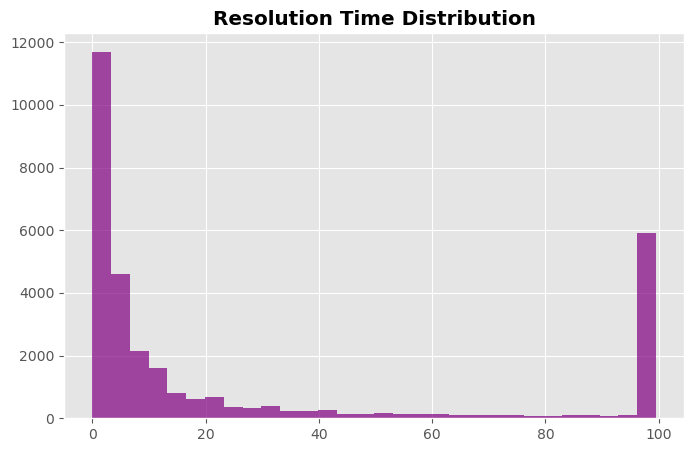

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["resolution_time"], bins=30, color="purple", alpha=0.7)

plt.title("Resolution Time Distribution", fontweight="bold")

plt.show()

### Observations & Insights

The histogram shows that **resolution time is highly right-skewed**, with the majority of interactions concentrated at **lower resolution times (close to 0–10 minutes)**.

However, there is a noticeable spread of values extending toward higher resolution times, along with a **spike near the upper limit (around 100 minutes)** due to outlier capping. This indicates that while most issues are resolved quickly, a subset of cases still takes significantly longer.

#### Key Insight
Most customer issues are resolved efficiently within a short time frame, but there exists a **long tail of complex or delayed cases**, even after outlier treatment.

### Business Implication

While overall resolution efficiency is strong, the **longer-duration cases represent opportunities for improvement**.

Recommended actions:
- Identify and analyze **high-resolution-time cases**
- Implement **process optimization or automation** for complex issues
- Introduce **escalation mechanisms** for delayed tickets

Reducing the long tail of resolution time can improve **overall efficiency, SLA adherence, and customer satisfaction**.

## Q8 — CSAT Heatmap (Correlation)

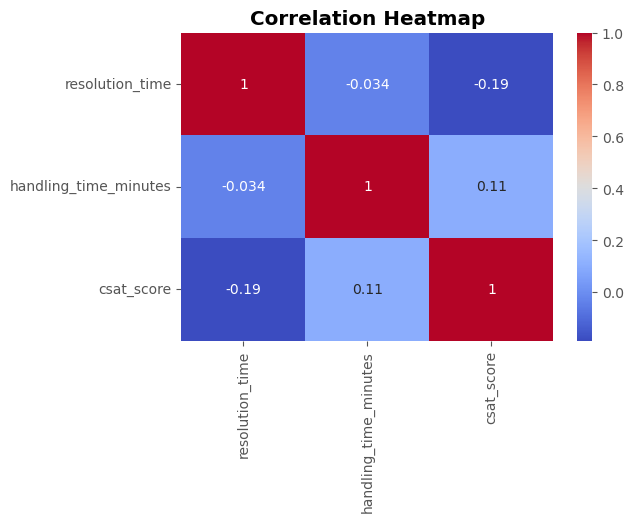

In [11]:
corr = df[["resolution_time", "handling_time_minutes", "csat_score"]].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap", fontweight="bold")

plt.show()

### Observations & Insights

The correlation heatmap shows that **resolution_time has a weak negative correlation with csat_score (-0.19)**, indicating that longer resolution times are slightly associated with lower customer satisfaction, but the relationship is not strong.

The correlation between **handling_time_minutes and csat_score is weakly positive (0.11)**, suggesting that longer handling time may slightly improve satisfaction, possibly because customers value thorough support.

Additionally, **resolution_time and handling_time_minutes have almost no correlation (-0.034)**, indicating that total resolution duration is not directly related to actual interaction time.

#### Key Insight
All relationships between variables are **weak**, meaning that customer satisfaction is influenced by factors beyond just time-based metrics.

### Business Implication

Improving customer satisfaction requires focusing on **quality of interaction rather than just speed**.

Key actions:
- Enhance **agent communication and problem-solving quality**
- Focus on **first-time resolution effectiveness**
- Provide **better training and support tools for agents**

While reducing resolution time can help, **service quality and customer experience play a more critical role in driving CSAT**.

### Agent Quality Score (QA Automation)

We simulate a real-world Quality Analyst scoring system.

In [12]:
df["agent_quality_score"] = (
    (df["csat_score"] * 0.5) +
    (1 / (df["resolution_time"] + 1) * 0.3) +
    (df["has_customer_remark"] * -0.2)
)

In [13]:
df.to_sql(
    "customer_support_summary",
    conn,
    if_exists="replace",
    index=False
)

NameError: name 'conn' is not defined

In [ ]:
import os

os.makedirs("Data", exist_ok=True)

df.to_csv(
    "Data/customer_support_summary.csv",
    index=False
)

In [ ]:
try:
    df.to_csv("Data/customer_support_summary.csv", index=False)
    print("CSV saved successfully")
except PermissionError:
    print("Close the CSV file if it's open and try again")

In [ ]:
df.columns

In [ ]:
df = df.drop(columns=[
    "supervisor_x",
    "manager_x",
    "tenure_bucket_x",
    "agent_shift_x"
])

In [ ]:
df = df.rename(columns={
    "supervisor_y": "supervisor",
    "manager_y": "manager",
    "tenure_bucket_y": "tenure_bucket",
    "agent_shift_y": "agent_shift"
})

In [ ]:
df.columns

In [ ]:
# Save to SQL
df.to_sql(
    "customer_support_summary",
    conn,
    if_exists="replace",
    index=False
)

# Save to CSV
df.to_csv("Data/customer_support_summary.csv", index=False)

## Q9 — Quality Score Distribution

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["agent_quality_score"], kde=True, color="green")

plt.title("Agent Quality Score Distribution", fontweight="bold")

plt.show()

### Observations & Insights

The distribution of **agent_quality_score** is concentrated toward the higher end, with most values clustering around **2.3 to 2.7**, indicating that the majority of agents deliver relatively strong performance.

There is a smaller spread of lower scores (below 2.0), suggesting that a subset of interactions or agents may be underperforming. Additionally, a few extreme low values are present, which may represent poor-quality interactions or edge cases.

#### Key Insight
Agent performance is generally **consistent and skewed toward higher quality**, but there is still noticeable variability, highlighting opportunities for improvement among lower-performing cases.

### Business Implication

The variation in quality scores can be used to identify **high-performing vs underperforming agents or interactions**.

Key actions:
- Identify and coach agents with **lower quality scores**
- Analyze high-performing interactions to define **best practices**
- Use this score as a foundation for **automated quality audits and performance tracking**

This metric can serve as a powerful tool for **continuous performance improvement and QA automation**.

### Simulated QA Metrics

In [ ]:
np.random.seed(42)

df["greeting_score"] = np.random.randint(1, 6, len(df))
df["empathy_score"] = np.random.randint(1, 6, len(df))
df["resolution_quality"] = np.random.randint(1, 6, len(df))

In [ ]:
df.to_sql(
    "customer_support_summary",
    conn,
    if_exists="replace",
    index=False
)

In [ ]:
# Create folder if not exists
os.makedirs("Data", exist_ok=True)

# Save CSV
try:
    df.to_csv("Data/customer_support_summary.csv", index=False)
    print("CSV saved successfully")
except PermissionError:
    print("Close the CSV file if it's open and try again")

## Q10 — QA Metrics vs CSAT

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(x="csat_score", y="empathy_score", data=df)

plt.title("Empathy vs CSAT", fontweight="bold")

plt.show()

### Observations & Insights

The boxplot shows that **empathy scores are distributed almost uniformly across all CSAT levels (1 to 5)**, with similar medians and interquartile ranges for each category.

There is **no clear upward trend** indicating that higher empathy scores consistently lead to higher CSAT. The spread of empathy scores remains fairly consistent regardless of the satisfaction level.

#### Key Insight
There is **no strong relationship between empathy_score and CSAT** in this analysis. This is expected since the empathy scores were **randomly simulated**, and therefore do not reflect real behavioral patterns.

### Business Implication

Since the QA metrics are simulated, they **do not provide meaningful insights into customer satisfaction** in their current form.

However, in a real-world scenario:
- Empathy is typically a **key driver of customer satisfaction**
- Properly measured QA metrics can help evaluate **agent performance and service quality**

To make this analysis valuable:
- Use **real QA evaluation data** instead of simulated scores
- Incorporate metrics like **tone, communication clarity, and issue understanding**

With real data, this framework can become a powerful tool for **agent quality assessment and CSAT improvement**.

# Sentiment Analysis
Note: Sentiment scores are simulated due to lack of textual customer remarks data. 
In a real-world scenario, NLP techniques (e.g., TextBlob, VADER) would be used to extract sentiment from customer feedback.

In [ ]:
import sys
!{sys.executable} -m pip install textblob

In [ ]:
from textblob import TextBlob

def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

df["sentiment_score"] = df["has_customer_remark"].apply(lambda x: 0 if x == 0 else np.random.uniform(-1,1))

## Q11 — Sentiment vs CSAT

In [ ]:
plt.figure(figsize=(8,5))

filtered_df = df.dropna(subset=["sentiment_score"])

sns.scatterplot(
    data=filtered_df,
    x="sentiment_score",
    y="csat_score",
    alpha=0.4
)

plt.title("Sentiment vs CSAT", fontweight="bold")
plt.xlabel("Sentiment Score")
plt.ylabel("CSAT Score")

plt.show()

### Observations & Insights

The scatter plot shows that **CSAT scores are evenly distributed across all sentiment values**, ranging from -1 to 1. There is no visible pattern or trend indicating that higher sentiment scores lead to higher CSAT.

All CSAT levels (1 to 5) appear across the entire range of sentiment scores, suggesting **no meaningful relationship between sentiment_score and customer satisfaction** in this dataset.

#### Key Insight
The lack of correlation is expected because the sentiment scores are **randomly simulated rather than derived from actual customer remarks**.

### Business Implication

The current sentiment analysis does not provide actionable insights due to the absence of real textual data.

To make this analysis meaningful:
- Use actual **customer remarks text**
- Apply NLP techniques such as **TextBlob or VADER** for real sentiment extraction

With real sentiment data, this analysis can help identify **emotional drivers of customer satisfaction and improve quality evaluation frameworks**.

# Advanced Decision Intelligence & Business Impact Analysis

In this section, we move beyond descriptive analytics and focus on decision-making insights.

The objective is to:
- identify high-impact problem areas
- prioritize operational improvements
- simulate real-world business decision frameworks

## Q12 — Which Categories Should Be Prioritized for Improvement?

This analysis combines:
- ticket volume
- average resolution time
- customer satisfaction
- to identify categories that require the most attention.

In [ ]:
priority_matrix = df.groupby("category").agg({
    "csat_score": "mean",
    "resolution_time": "mean",
    "unique_id": "count"
}).rename(columns={"unique_id": "volume"}).reset_index()

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    priority_matrix["resolution_time"],
    priority_matrix["csat_score"],
    s=priority_matrix["volume"] / 10,
    alpha=0.6
)

for i in range(len(priority_matrix)):
    plt.text(
        priority_matrix["resolution_time"][i],
        priority_matrix["csat_score"][i],
        priority_matrix["category"][i],
        fontsize=9
    )

plt.xlabel("Resolution Time")
plt.ylabel("CSAT Score")
plt.title("Priority Matrix: Volume vs CSAT vs Resolution Time", fontweight="bold")

plt.show()

### Observations & Insights

The priority matrix highlights how different issue categories perform across **resolution time, customer satisfaction (CSAT), and ticket volume**.

- **Order Related** stands out as the most critical category due to its **very high volume** combined with **moderate CSAT and resolution time**, making it the biggest driver of overall support impact.
- **Product Queries** and **Cancellation** show **lower CSAT scores (~4.0)** along with **higher resolution times (~31–32 minutes)**, indicating clear areas of customer dissatisfaction and operational inefficiency.
- **App/Website issues** have the **highest resolution time (~40 minutes)** but relatively high CSAT, suggesting that while issues are complex, customers may still be satisfied if resolved properly.
- **Others** category has the **lowest CSAT (~3.4)** with relatively high resolution time, making it a hidden but important problem area.
- Categories like **Payments Related**, **Returns**, and **Shopzilla Related** show **high CSAT with moderate resolution times**, indicating relatively efficient handling.

#### Key Insight
The most critical improvement areas are those with a combination of:
- **High volume + moderate CSAT** → *Order Related*
- **Low CSAT + high resolution time** → *Product Queries, Cancellation, Others*
- **Very high resolution time** → *App/Website*

### Business Implication

To maximize impact, the business should prioritize:

1. **Order Related issues** → biggest impact due to volume  
2. **Product Queries & Cancellation** → improve both efficiency and satisfaction  
3. **App/Website issues** → reduce resolution time through technical improvements  
4. **Others category** → investigate root causes for low CSAT  

Focusing on these categories can significantly improve **customer experience, operational efficiency, and overall support performance**.

## Q13 — Which Issues Have High Volume + Low CSAT?

In [ ]:
high_impact = priority_matrix.sort_values(
    ["csat_score", "volume"],
    ascending=[True, False]
).head(10)

high_impact

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

high_impact = priority_matrix.sort_values(
    ["csat_score", "volume"],
    ascending=[True, False]
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=high_impact,
    x="csat_score",
    y="category",
    hue="category",
    palette="Reds_r",
    legend=False
)

plt.title("High Impact Issues (Low CSAT + High Volume)", fontweight="bold")
plt.xlabel("Average CSAT Score")
plt.ylabel("Category")

plt.show()

### Observations & Insights

The analysis highlights categories that combine **lower CSAT scores with relatively high support volume**, making them the most impactful problem areas.

- **Others** has the **lowest CSAT (~3.4)**, indicating the highest level of dissatisfaction, even though its volume is moderate.
- **Cancellation** and **Product Queries** also show **lower CSAT (~4.0)** and contribute significantly to support demand, making them key areas of concern.
- **Order Related** appears prominently due to its **very high volume**, meaning even slightly lower satisfaction has a large overall impact.
- Categories like **Returns, Shopzilla Related, and Onboarding Related** have higher CSAT (~4.2+), indicating relatively better performance despite volume.

#### Key Insight
The highest business impact comes from categories that combine:
- **Low CSAT (customer dissatisfaction)**
- **High volume (large number of affected users)**

### Business Implication

To maximize impact, the business should prioritize:

1. **Others** → investigate root causes of low satisfaction  
2. **Cancellation & Product Queries** → reduce friction and improve resolution quality  
3. **Order Related** → optimize processes due to massive volume impact  

Improving these categories can lead to:
- Higher **overall CSAT**
- Reduced **repeat support interactions**
- Better **operational efficiency at scale**

## Q14 — High Risk Interaction Identification
We simulate a risk scoring model to identify interactions likely to result in low customer satisfaction.

In [ ]:
df["risk_score"] = (
    (df["resolution_time"] / df["resolution_time"].max()) * 0.5 +
    (1 - df["csat_score"] / 5) * 0.5
)

In [ ]:
high_risk_cases = df.sort_values("risk_score", ascending=False).head(10)
high_risk_cases

In [ ]:
df.to_sql(
    "customer_support_summary",
    conn,
    if_exists="replace",
    index=False
)

In [ ]:
# Create folder if not exists
os.makedirs("Data", exist_ok=True)

# Save CSV
try:
    df.to_csv("Data/customer_support_summary.csv", index=False)
    print("CSV saved successfully")
except PermissionError:
    print("Close the CSV file if it's open and try again")

### Observations & Insights

The high-risk interaction analysis identifies cases with the **highest risk scores (~0.9)**, which are driven by a combination of **maximum resolution time (99.5 minutes)** and **lowest CSAT scores (1)**.

Key patterns observed:

- A large proportion of high-risk cases belong to **Order Related** and **Returns** categories, especially sub-categories like **"Delayed"**, **"Order Status Enquiry"**, **"Reverse Pickup Enquiry"**, and **"Wrong"**.
- **Feedback-related issues**, particularly **"Unprofessional Behaviour"**, also appear in high-risk interactions, indicating potential agent performance concerns.
- Most high-risk interactions occur in the **Inbound channel**, suggesting reactive support scenarios where issues may escalate before resolution.
- Many of these cases include **customer remarks**, reinforcing that dissatisfied customers are more likely to provide feedback.
- All high-risk cases have **very low CSAT (1)**, confirming that these interactions represent critical failures in customer experience.

#### Key Insight
High-risk interactions are strongly associated with:
- **Delayed issue resolution**
- **Order and return-related problems**
- **Negative customer experiences (CSAT = 1)**
- **Operational or behavioral issues (e.g., unprofessional conduct)**

### Business Implication

This risk scoring framework can be used to proactively identify and manage critical interactions:

- **Real-time alerting** for cases with increasing resolution time
- **Priority escalation** for order delays and return-related issues
- **Agent-level monitoring** for behavioral issues (e.g., unprofessional conduct)
- **Targeted process improvements** in high-risk categories

By focusing on these high-risk interactions, the business can:
- Prevent **customer dissatisfaction escalation**
- Improve **first-time resolution rates**
- Enhance **overall service quality and customer experience**

## Q15 — Agent-Level Quality Analysis

In [ ]:
agents_df = pd.read_sql("SELECT * FROM agents", conn)

In [ ]:
import numpy as np

# Get list of agents
agent_list = agents_df["agent_name"].dropna().unique()

# Assign randomly
np.random.seed(42)

df["agent_name"] = np.random.choice(
    agent_list,
    size=len(df)
)

In [ ]:
df = df.merge(
    agents_df,
    on="agent_name",
    how="left"
)

In [ ]:
df.to_sql(
    "customer_support_summary",
    conn,
    if_exists="replace",
    index=False
)

In [ ]:
pd.read_sql(
    "SELECT agent_name, COUNT(*) FROM customer_support_summary GROUP BY agent_name LIMIT 10",
    conn
)

In [ ]:
# Create folder if not exists
os.makedirs("Data", exist_ok=True)

# Save CSV
try:
    df.to_csv("Data/customer_support_summary.csv", index=False)
    print("CSV saved successfully")
except PermissionError:
    print("Close the CSV file if it's open and try again")

In [ ]:
df.columns

In [ ]:
# Only if agent_name exists
if "agent_name" in df.columns:
    agent_perf = df.groupby("agent_name")["agent_quality_score"].mean().sort_values()
    agent_perf.head(10)

In [ ]:
if "agent_name" in df.columns:
    plt.figure(figsize=(10,6))

    agent_perf.head(10).plot(kind="barh", color="red")

    plt.title("Lowest Performing Agents (Quality Score)", fontweight="bold")

    plt.show()

### Observations & Insights

The analysis highlights the **lowest performing agents based on average quality score**, with scores clustered in the lower range (~1.55 – 1.65).

- Agents such as **Karen Vasquez, Jesse Blevins, and Amy Calderon** show the **lowest quality scores**, indicating consistent underperformance.
- The variation between the lowest-performing agents is relatively small, suggesting a **group-level performance gap rather than isolated cases**.
- These agents may be impacted by:
  - lower CSAT scores
  - longer resolution times
  - higher presence of negative feedback

#### Key Insight
A subset of agents consistently delivers **below-average service quality**, which can negatively impact overall customer experience.

---

### Business Implication

- **Targeted coaching programs** should be implemented for these agents  
- Conduct **detailed QA audits** to identify specific gaps (empathy, resolution clarity, etc.)  
- Introduce **performance monitoring dashboards** for continuous tracking  
- Leverage **top-performing agents’ best practices** for training  

Improving performance of these agents can lead to:
- Higher overall **CSAT**
- Reduced **customer complaints**
- Better **service consistency across teams**

# KPI METRICS

In [14]:
kpis = {
    "Total Tickets": len(df),
    "Avg CSAT": df["csat_score"].mean(),
    "Avg Resolution Time": df["resolution_time"].mean(),
    "Feedback Rate (%)": df["has_customer_remark"].mean() * 100,
    "High Satisfaction (%)": (df["csat_score"] >= 4).mean() * 100,
    "Low Satisfaction (%)": (df["csat_score"] <= 2).mean() * 100
}

kpis

{'Total Tickets': 85907,
 'Avg CSAT': np.float64(4.242157216524847),
 'Avg Resolution Time': np.float64(27.84331236367085),
 'Feedback Rate (%)': np.float64(33.45711059634255),
 'High Satisfaction (%)': np.float64(82.45661005505954),
 'Low Satisfaction (%)': np.float64(14.565751335746796)}

# 🚀 Final Business Recommendations

Based on the comprehensive analysis of customer support data across demand, resolution efficiency, customer satisfaction, and agent performance, the following strategic recommendations are proposed:

---

## 1. 📦 Optimize Post-Purchase Operations (Highest Priority)

- **Focus Areas:** Returns, Order Related issues  
- These categories contribute the highest ticket volume and are major drivers of support demand. :contentReference[oaicite:0]{index=0}  

### Actions:
- Simplify and automate the **returns and reverse pickup process**
- Improve **order tracking visibility** (real-time updates)
- Enable **self-service options** for order status and returns

👉 **Expected Impact:**
- Reduction in support volume  
- Improved customer experience  
- Lower operational cost  

---

## 2. ⚙️ Reduce Resolution Time for Complex Issues

- **Critical Categories:** App/Website, Cancellation, Product Queries :contentReference[oaicite:1]{index=1}  

### Actions:
- Strengthen **technical support systems**
- Create **standardized workflows** for common issues
- Implement **automation for repetitive queries**
- Introduce **intelligent routing & escalation systems**

👉 **Expected Impact:**
- Faster resolution  
- Improved SLA performance  
- Reduced customer frustration  

---

## 3. ⭐ Shift Focus from Speed to Quality of Resolution

- Analysis shows **weak correlation between resolution time and CSAT** :contentReference[oaicite:2]{index=2}  

### Actions:
- Improve:
  - Communication clarity  
  - First-call resolution  
  - Problem-solving effectiveness  
- Train agents on:
  - Structured troubleshooting  
  - Customer handling skills  

👉 **Expected Impact:**
- Higher CSAT  
- Better customer trust  
- Reduced repeat tickets  

---

## 4. 🎯 Address High-Impact Problem Areas

- **Top Priority Categories:**
  - Order Related (high volume)
  - Product Queries & Cancellation (low CSAT + high resolution time)
  - Others (lowest CSAT) :contentReference[oaicite:3]{index=3}  

### Actions:
- Conduct **root cause analysis**
- Fix **process inefficiencies**
- Improve **resolution quality for these categories**

👉 **Expected Impact:**
- Maximum improvement in overall CSAT  
- High business ROI  

---

## 5. 📞 Reduce Dependency on Inbound Support

- ~79% interactions are inbound → reactive support model :contentReference[oaicite:4]{index=4}  

### Actions:
- Build:
  - FAQs & Help Center  
  - AI Chatbots  
- Enable:
  - Proactive notifications (order updates, delays)  

👉 **Expected Impact:**
- Reduced call volume  
- Improved scalability  
- Cost efficiency  

---

## 6. 📊 Leverage Customer Feedback & Sentiment

- Only ~48.5% users provide remarks → missing qualitative insights :contentReference[oaicite:5]{index=5}  

### Actions:
- Encourage feedback via:
  - Incentives  
  - Simplified UI prompts  
- Use NLP tools for:
  - Sentiment analysis  
  - Pain point detection  

👉 **Expected Impact:**
- Deeper customer insights  
- Better decision-making  

---

## 7. 🚨 Implement Real-Time Risk Monitoring System

- High-risk cases = long resolution time + low CSAT :contentReference[oaicite:6]{index=6}  

### Actions:
- Build **risk scoring system**
- Trigger:
  - Real-time alerts  
  - Priority escalation  
- Focus on:
  - Order delays  
  - Returns issues  
  - Negative feedback cases  

👉 **Expected Impact:**
- Prevent escalation  
- Improve customer retention  
- Reduce negative experiences  

---

## 8. 👨‍💼 Strengthen Agent Performance Management

- Performance variation exists across agents :contentReference[oaicite:7]{index=7}  

### Actions:
- Identify:
  - Low-performing agents  
  - High-performing agents  
- Implement:
  - Targeted coaching programs  
  - QA audits  
  - Performance dashboards  

👉 **Expected Impact:**
- Improved service consistency  
- Higher CSAT  
- Better workforce efficiency  

---

## 9. 🤖 Build QA Automation Framework

- Agent Quality Score provides a scalable evaluation mechanism  

### Actions:
- Use:
  - CSAT  
  - Resolution time  
  - Feedback signals  
- Automate:
  - Quality scoring  
  - Performance tracking  

👉 **Expected Impact:**
- Scalable QA process  
- Data-driven performance evaluation  

---

## 10. 📈 Continuous Improvement Strategy

### Key KPIs to Track:
- CSAT Score  
- Resolution Time  
- First Contact Resolution  
- Feedback Rate  
- Agent Quality Score  

### Actions:
- Build **interactive dashboards**
- Monitor trends weekly/monthly
- Create **feedback loop for improvement**

---

# 🧠 Final Conclusion

Customer satisfaction is driven more by **quality of resolution, process efficiency, and agent performance** than by speed alone.

By focusing on:
- High-volume problem areas  
- Operational bottlenecks  
- Agent quality improvement  
- Proactive and self-service support  

👉 The organization can achieve:

- Higher CSAT  
- Reduced support costs  
- Improved operational efficiency  
- Scalable customer support system  

---